# ML - Aprendizaje No Supervisado

---





## Clustering
Es una técnica de aprendizaje no supervisado de IA, tiene como objetivo agrupar datos en clusters (grupos) donde los elementos sean: similares entre sí dentro del mismo grupo y diferentes de los datos grupos.
### K-Means
K-Means es uno de los algortimos más usafos para hacer clustering, se encarha de dividar los datos en K grupos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import random #para los centroides
#el número de centroides se elige de forma aleatoria entre 1 y 20
n_centers = random.randint(1, 20)
#generamos los centros con la distancia mínima garantizada
#cada nuevo candidato se acepta solo si está a mas de 5 unidades
blob_centers=[]
while len(blob_centers)<n_centers:
    candidate=np.random.uniform(-10,10,2)
    if all(np.linalg.norm(candidate-center)>5 for center in blob_centers):
        blob_centers.append(candidate)
blob_centers= np.array(blob_centers)
blob_std = np.full(n_centers, 0.8) #clusters compactos)
#generamos muestras con make blobs
X, y = make_blobs(n_samples=2000, centers=blob_centers, 
                  cluster_std=blob_std, random_state=42)
print(f"Se generaron {n_centers} centroides (aleatorio entre 1 y 20)")
print("Coordenadas de los centroides:")
print(blob_centers)

Se generaron 16 centroides (aleatorio entre 1 y 20)
Coordenadas de los centroides:
[[ 2.88949222  6.27409848]
 [ 1.62185121 -3.79802698]
 [ 8.38322357  3.11924463]
 [-5.07008477  8.64725461]
 [ 6.39184554 -7.14081494]
 [-0.97381268  2.74227826]
 [-5.31783465 -9.92303646]
 [-9.7147644  -1.87048923]
 [ 8.50612783 -2.04942234]
 [-6.53852708  3.70079489]
 [-3.48647678 -3.4600524 ]
 [ 8.19294622  8.39895352]
 [-0.1643434  -9.57775388]
 [-9.78407733 -7.52962177]
 [ 4.00153676  0.62253015]
 [-9.94966667  9.93820941]]


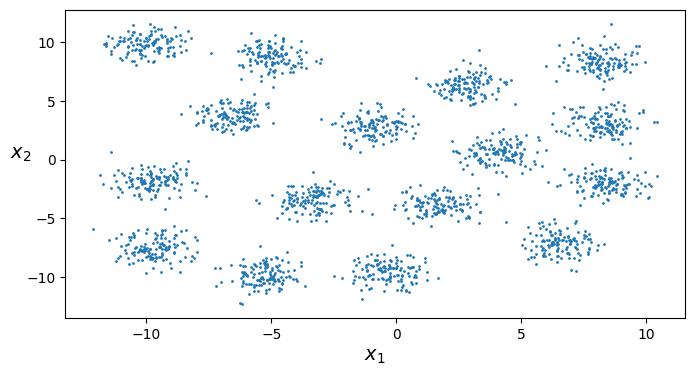

In [2]:
import matplotlib.pyplot as plt

# c=y colorea cada punto segun su grupo — sin etiquetas los puntos son todos del mismo color
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

plt.figure(figsize=(8, 4))
plot_clusters(X)  # sin y=sin colores
plt.show()

Esta gráfica representa el estado inicial 
antes de que el modelo trabaje. K-Means deberá descubrir por sí solo la estructura que hay.

In [3]:
# Aplicamos K-Means con k = n_centros sobre los datos sinteticos
# KMeans asigna cada punto al centroide mas cercano usando distancia euclidiana
from sklearn.cluster import KMeans

k = len(blob_centers)    # usamos el mismo numero de centros que generamos
kmeans= KMeans(n_clusters=k, random_state=42)
y_pred= kmeans.fit_predict(X)


In [4]:
kmeans.cluster_centers_

array([[ -0.88063924,   2.81830971],
       [  8.41899235,  -2.03112427],
       [ -5.30021298,  -9.83421127],
       [ -9.76137642,  -1.82412265],
       [-10.00751427,   9.83825194],
       [  8.16501041,   8.35902921],
       [  1.71184745,  -3.83453691],
       [  2.82511541,   6.33459864],
       [  4.08499711,   0.58696764],
       [ -3.34918244,  -3.44564627],
       [ -9.71195664,  -7.52583842],
       [ -6.58762615,   3.74919771],
       [  6.52852994,  -7.09955373],
       [ -4.99571777,   8.74534184],
       [  8.28369496,   3.09254273],
       [ -0.33929729,  -9.53798833]])

`cluster_centers_` contiene las coordenadas de los centroides que encontró el modelo. 
Podemos comparar estos valores con los `blob_centers` originales para verificar que 
K-Means recuperó correctamente la estructura del dataset sintético.

In [5]:
# Funciones  para visualizar fronteras de decision
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)
    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

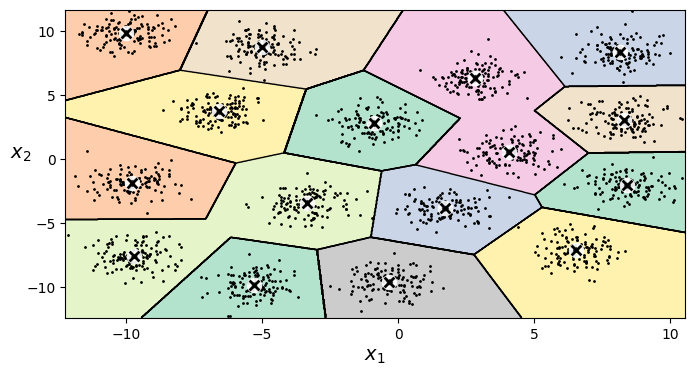

In [6]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

Cada zona de color representa un cluster. Los centroides aparecen marcados con un 
círculo blanco y una cruz negra. Visualmente podemos verificar que K-Means agrupó 
correctamente los puntos según los centroides que generamos.

---
## Metodo del Codo y Silhouette Score — Datos Sinteticos

Para los datos sinteticos evaluamos distintos valores de k entre **2 y el doble de los centroides generados**.
El **metodo del codo** busca el punto donde la inercia deja de bajar bruscamente.
El **Silhouette Score** mide que tan bien separados estan los clusters (1 = perfecto, -1 = incorrecto).

In [7]:
#Silhouette Score
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

0.7010509089516826

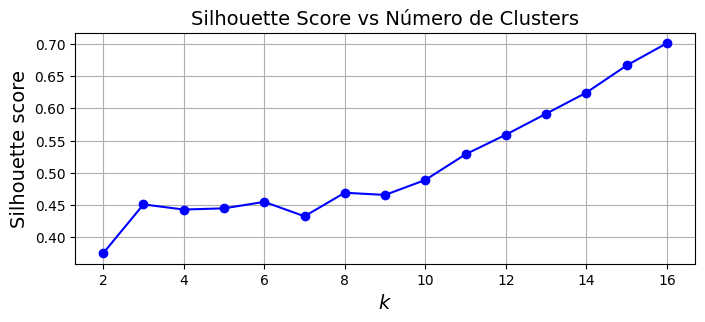

In [8]:
from sklearn.metrics import silhouette_score

max_k= min(20, len(blob_centers))
kmeans_per_k =[KMeans(n_clusters=k, random_state=42).fit(X) for k in range (1, max_k+1)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]] 

ks=list(range(2, max_k +1))
plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

# Método del Codo (Elbow Method)

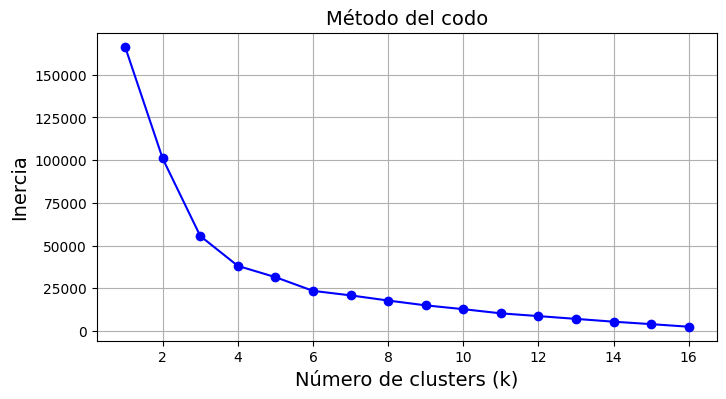

In [9]:
inertias= []
K = range(1, max_k+1)
for k in K:
    kmeans= KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)
plt.figure(figsize=(8, 4))
plt.plot(K, inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del codo", fontsize=14)
plt.grid(True)
plt.show() 

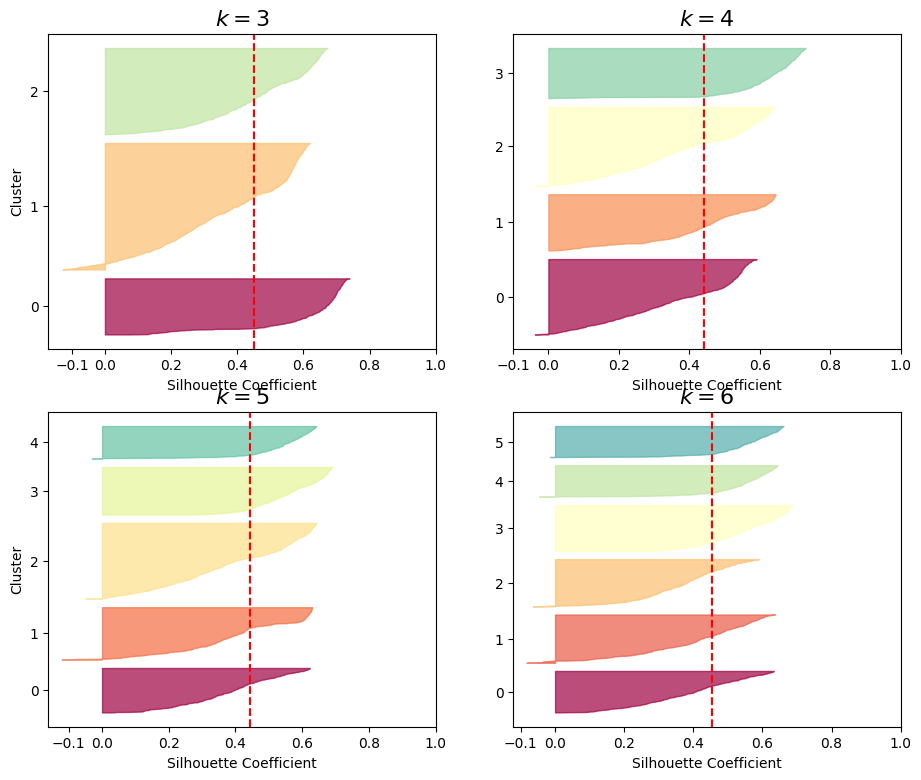

In [10]:
#Diagrama de Silhouette
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

valid_ks = [k for k in (3, 4, 5, 6) if k <= len(kmeans_per_k)]

for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()
        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")
    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")
    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

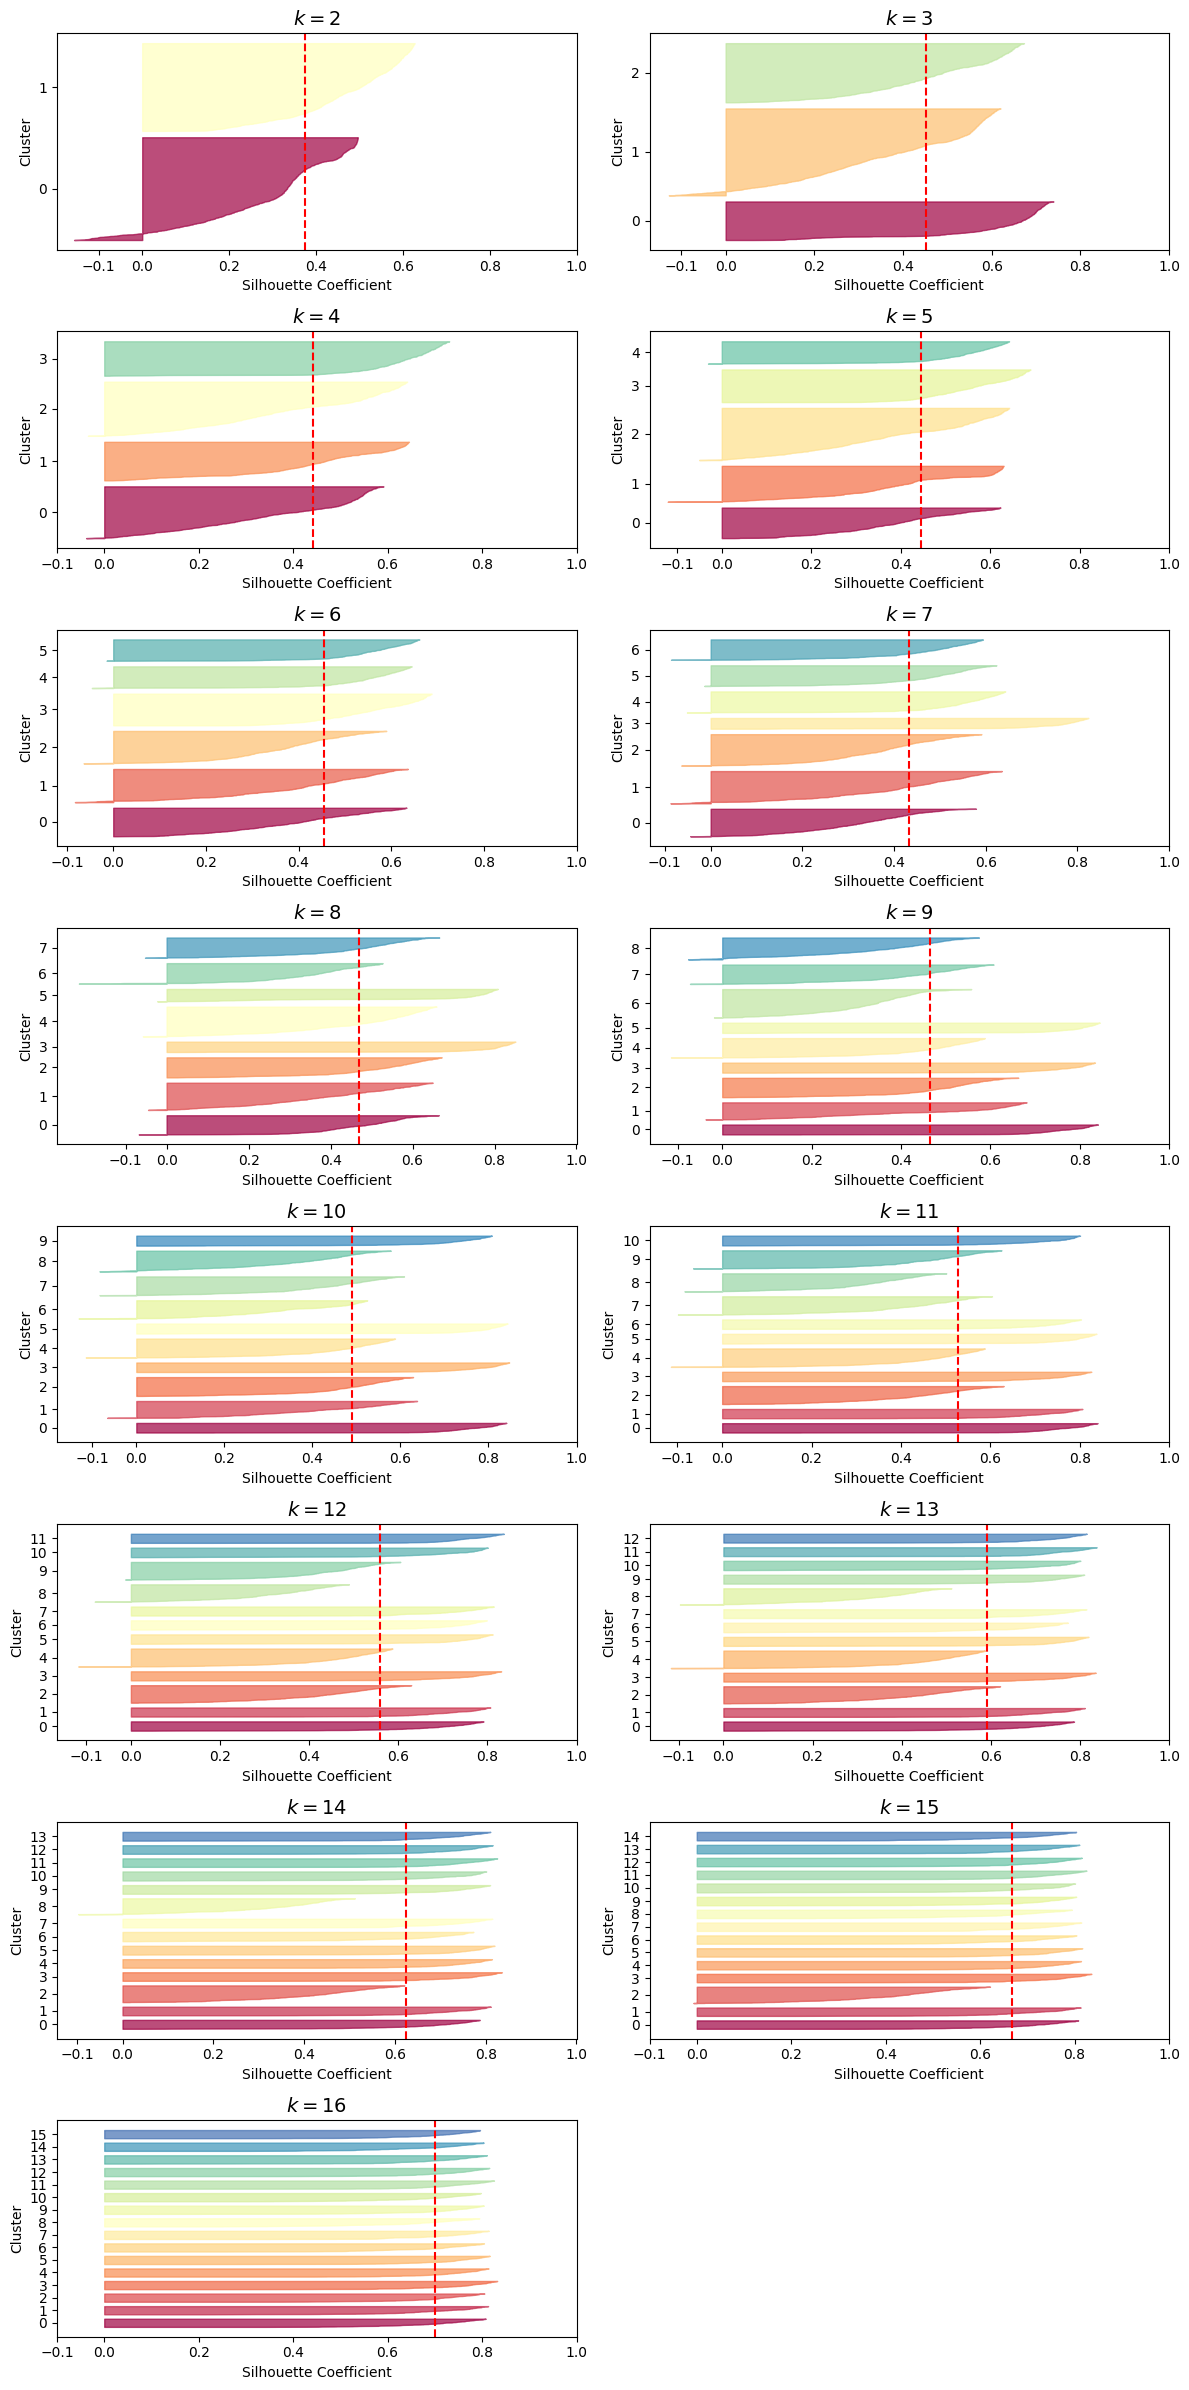

In [11]:
#diagram de silueta para todos los k
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

n_ks = len(kmeans_per_k)
plt.figure(figsize=(12, 3 * ((n_ks - 1) // 2 + 1)))

for plot_idx, k in enumerate(range(2, n_ks + 1)):
    plt.subplot((n_ks - 1) // 2 + 1, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()
        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")
    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")
    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=14)

plt.tight_layout()
plt.show()

La línea roja punteada indica el Silhouette Score promedio del cluster. Los clusters cuyas 
barras superan esa línea están bien definidos. Si muchas barras quedan por debajo, 
ese valor de k no es el óptimo.

---
## K-Means con 2 Dimensiones (PCA)

## Dataset Utilizado
El dataset GTSRB (German Traffic Sign Recognition Benchmark) contiene imágenes de señales de tránsito reales tomadas en condiciones variables de iluminación, ángulo y resolución. Características principales:

•	Total de imágenes usadas: 12.000 (muestra aleatoria del conjunto de entrenamiento)

•	Número de clases: 43 tipos de señales de tránsito

•	Resolución normalizada: 32x32 píxeles en escala de grises

•	Características por imagen: 1024 (vectores aplanados, normalizados a [0,1])


In [12]:
import numpy as np
import pandas as pd
import cv2
import os

DATASET_PATH = "."    
IMG_SIZE     = 32     # redimensionamos cada imagen a 32x32 píxeles
N_SAMPLES    = 12000  # usamos 12.000 imágenes para que el clustering sea manejable

df_train = pd.read_csv(os.path.join(DATASET_PATH, "Train.csv"))
df_train = df_train.sample(n=N_SAMPLES, random_state=42).reset_index(drop=True)

y_real = df_train["ClassId"].values  # guardamos etiquetas solo para evaluar al final

imagenes = []
for ruta in df_train["Path"]:
    ruta_completa = os.path.join(DATASET_PATH, ruta)
    img = cv2.imread(ruta_completa, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    imagenes.append(img.flatten())

# cada fila es una imagen, cada columna un píxel — 1024 características por imagen
X_full = np.array(imagenes, dtype=np.float32) / 255.0

print("Dimensiones del dataset:", X_full.shape)   # esperado: (12000, 1024)
print("Número de clases reales:", len(np.unique(y_real)))  # esperado: 43

Dimensiones del dataset: (12000, 1024)
Número de clases reales: 43


Shape con 2 dimensiones (PCA): (12000, 2)
Varianza explicada: 66.25%


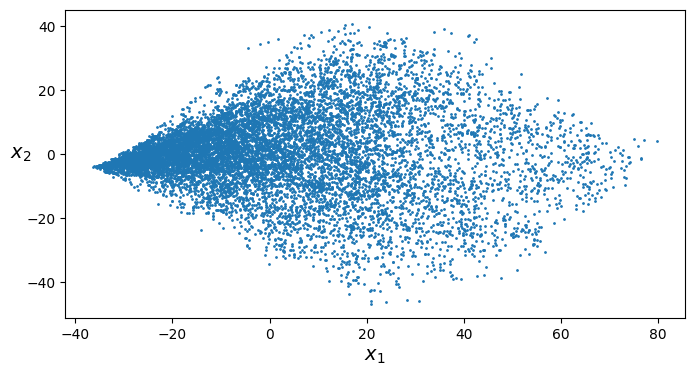

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

print("Shape con 2 dimensiones (PCA):", X_2d.shape)
print(f"Varianza explicada: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

plt.figure(figsize=(8, 4))
plot_clusters(X_2d)
plt.show()

In [14]:
from sklearn.cluster import KMeans
kmeans= KMeans(n_clusters=43, random_state=42)
kmeans.fit(X_2d)
kmeans.cluster_centers_

array([[-18.838068  ,   0.64952314],
       [ 26.628574  ,   3.1319816 ],
       [  1.2632464 ,  10.309295  ],
       [  7.662992  , -10.132941  ],
       [ 49.34722   ,  -6.009472  ],
       [ 21.687647  ,  21.623549  ],
       [-28.451586  ,  -2.0220783 ],
       [ 29.302462  , -35.078064  ],
       [ -9.468889  ,   1.8855572 ],
       [ 52.52924   ,   9.317891  ],
       [-11.00505   , -12.83117   ],
       [ -3.5042405 ,  -5.1187043 ],
       [ 10.808398  ,   6.771679  ],
       [ 61.220016  , -10.678027  ],
       [ -8.020235  ,   9.684763  ],
       [ 36.879467  , -11.341397  ],
       [ 30.581348  ,  16.340652  ],
       [ 25.226717  ,  -8.666213  ],
       [  4.4439263 , -24.06831   ],
       [ 11.228011  ,  30.998772  ],
       [-15.573402  ,   6.2400327 ],
       [-24.29516   ,  -4.373506  ],
       [ -1.7785316 ,   2.819015  ],
       [ 38.864273  , -24.32683   ],
       [ 13.455101  ,  22.03664   ],
       [ 19.576464  ,  12.546158  ],
       [-32.420692  ,  -3.3944705 ],
 

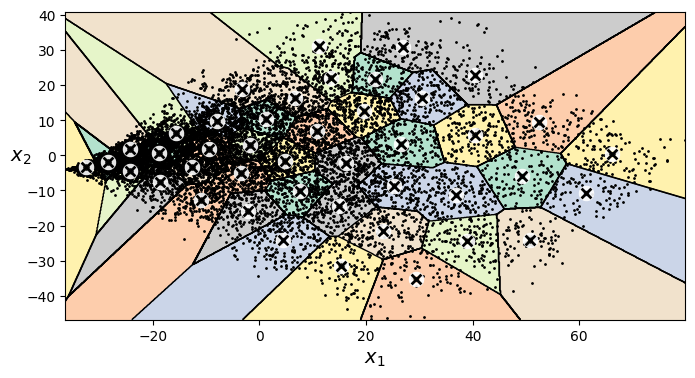

In [15]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X_2d)
plt.show()

Con solo 2 componentes principales (PCA), se captura solo una parte limitada de la varianza total de las imágenes. Por eso, los clusters (grupos) se superponen más que en el dataset sintético, ya que las señales de tránsito tienen mucha variabilidad visual que no puede representarse completamente en solo 2 dimensiones.

---
## K-Means con 3 Dimensiones (PCA)

In [16]:
pca_3d = PCA(n_components=3, random_state=42)
X_3d = pca_3d.fit_transform(X_scaled)

print("Shape con 3 dimensiones (PCA):", X_3d.shape)
print(f"Varianza explicada: {pca_3d.explained_variance_ratio_.sum()*100:.2f}%")

kmeans_3d = KMeans(n_clusters=43, random_state=42)
kmeans_3d.fit(X_3d)

kmeans.cluster_centers_

Shape con 3 dimensiones (PCA): (12000, 3)
Varianza explicada: 70.48%


array([[-18.838068  ,   0.64952314],
       [ 26.628574  ,   3.1319816 ],
       [  1.2632464 ,  10.309295  ],
       [  7.662992  , -10.132941  ],
       [ 49.34722   ,  -6.009472  ],
       [ 21.687647  ,  21.623549  ],
       [-28.451586  ,  -2.0220783 ],
       [ 29.302462  , -35.078064  ],
       [ -9.468889  ,   1.8855572 ],
       [ 52.52924   ,   9.317891  ],
       [-11.00505   , -12.83117   ],
       [ -3.5042405 ,  -5.1187043 ],
       [ 10.808398  ,   6.771679  ],
       [ 61.220016  , -10.678027  ],
       [ -8.020235  ,   9.684763  ],
       [ 36.879467  , -11.341397  ],
       [ 30.581348  ,  16.340652  ],
       [ 25.226717  ,  -8.666213  ],
       [  4.4439263 , -24.06831   ],
       [ 11.228011  ,  30.998772  ],
       [-15.573402  ,   6.2400327 ],
       [-24.29516   ,  -4.373506  ],
       [ -1.7785316 ,   2.819015  ],
       [ 38.864273  , -24.32683   ],
       [ 13.455101  ,  22.03664   ],
       [ 19.576464  ,  12.546158  ],
       [-32.420692  ,  -3.3944705 ],
 

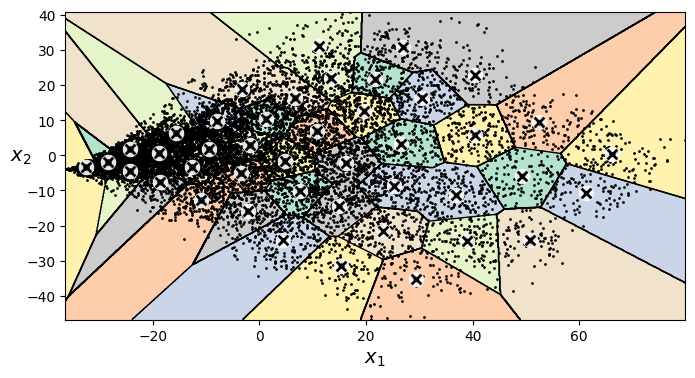

In [17]:
# Para graficar en 2D proyectamos usando PC1 y PC2 (dim 0 y 1)
# Los colores corresponden a los clusters encontrados en 3D
# La tercera componente (PC3) no se ve pero SI influyo en la asignacion de clusters
X_3d_plot = X_3d[:, :2]   # solo PC1 y PC2 para graficar

# Creamos un modelo auxiliar en 2D con los mismos centroides proyectados
# para poder usar plot_decision_boundaries del cuadernillo
from sklearn.cluster import KMeans

kmeans_3d_aux = KMeans(n_clusters=43, random_state=42)
kmeans_3d_aux.fit(X_3d_plot)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_3d_aux, X_3d_plot)
plt.show()

In [18]:
from sklearn.metrics import silhouette_score

inercias_gtsrb = []
silhouettes_gtsrb = []
rango_k_gtsrb = range(5, 61, 5)

for ki in rango_k_gtsrb:
    km = KMeans(n_clusters=ki, random_state=42, n_init=5)
    etiquetas = km.fit_predict(X_2d)
    inercias_gtsrb.append(km.inertia_)
    silhouettes_gtsrb.append(silhouette_score(X_2d, etiquetas, sample_size=3000))
    print(f"k={ki}  inercia={km.inertia_:.2f}  silhouette={silhouettes_gtsrb[-1]:.4f}")

k=5  inercia=1443909.25  silhouette=0.4046
k=10  inercia=728069.31  silhouette=0.3864
k=15  inercia=490120.94  silhouette=0.3623
k=20  inercia=372134.47  silhouette=0.3513
k=25  inercia=296509.22  silhouette=0.3476
k=30  inercia=248602.78  silhouette=0.3494
k=35  inercia=213750.88  silhouette=0.3354
k=40  inercia=189400.06  silhouette=0.3347
k=45  inercia=167492.38  silhouette=0.3388
k=50  inercia=151230.81  silhouette=0.3358
k=55  inercia=136518.62  silhouette=0.3368
k=60  inercia=125209.91  silhouette=0.3382


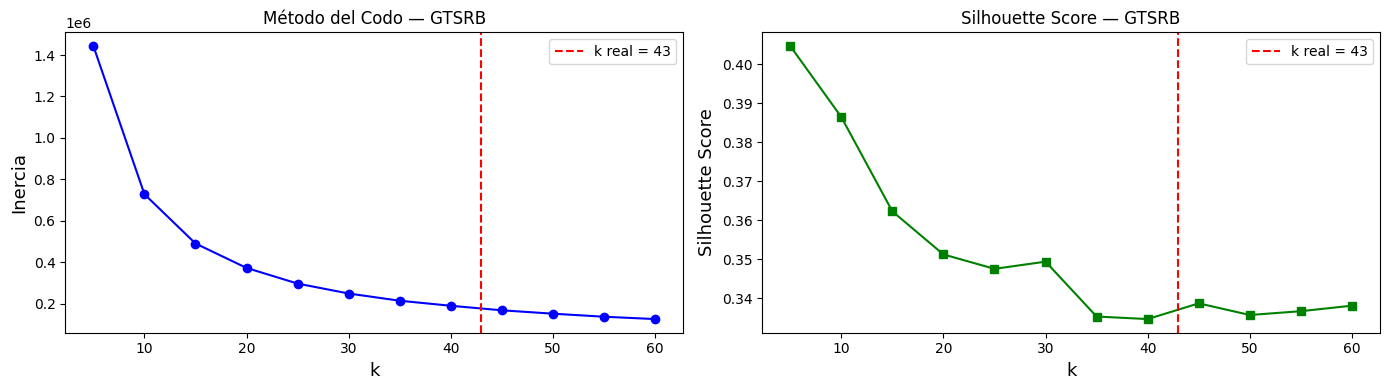

Mejor k según Silhouette: 5
Silhouette Score máximo: 0.4046


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(list(rango_k_gtsrb), inercias_gtsrb, 'bo-')
axes[0].axvline(x=43, color='r', linestyle='--', label='k real = 43')
axes[0].set_xlabel("k", fontsize=13)
axes[0].set_ylabel("Inercia", fontsize=13)
axes[0].set_title("Método del Codo — GTSRB")
axes[0].legend()

axes[1].plot(list(rango_k_gtsrb), silhouettes_gtsrb, 'gs-')
axes[1].axvline(x=43, color='r', linestyle='--', label='k real = 43')
axes[1].set_xlabel("k", fontsize=13)
axes[1].set_ylabel("Silhouette Score", fontsize=13)
axes[1].set_title("Silhouette Score — GTSRB")
axes[1].legend()

plt.tight_layout()
plt.show()

mejor_k = list(rango_k_gtsrb)[silhouettes_gtsrb.index(max(silhouettes_gtsrb))]
print(f"Mejor k según Silhouette: {mejor_k}")
print(f"Silhouette Score máximo: {max(silhouettes_gtsrb):.4f}")

---
## Aprendizaje Semi-Supervisado — GTSRB
El aprendizaje semi-supervisado aprovecha una pequeña cantidad de datos etiquetados junto con una gran cantidad de datos sin etiquetar. En este laboratorio se simula el escenario donde solo se pueden anotar manualmente 50 imágenes del total de 12.000.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Reducimos a 50 dimensiones con PCA — más información que en 2D
pca_50 = PCA(n_components=50, random_state=42)
X_50 = pca_50.fit_transform(X_scaled)

# Dividimos en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X_50, y_real, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (9600, 50)
y_train shape: (9600,)
X_test shape: (2400, 50)
y_test shape: (2400,)


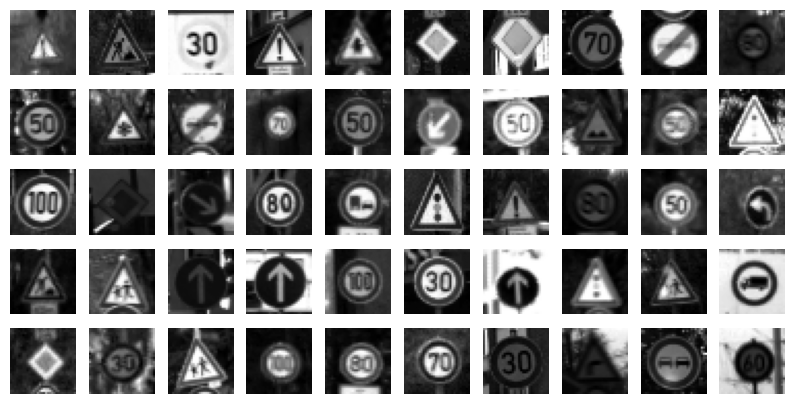

Precisión con representativas: 0.12083333333333333


C:\Users\usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1201: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


Precisión con aleatorias: 0.15
Precisión con etiquetas propagadas: 0.08


In [23]:
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression

k = 50
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)

idxs = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[idxs]

X_train_full_portion = X_full[:len(X_train)]
X_representative_digits_vis = X_train_full_portion[idxs]

plt.figure(figsize=(10, 5))
for index, X_representative_digit in enumerate(X_representative_digits_vis):
    plt.subplot(5, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(32, 32), cmap="gray")
    plt.axis('off')
plt.show()

y_representative_digits = y_train[idxs]

log_reg2 = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=42)
log_reg2.fit(X_representative_digits, y_representative_digits)
print("Precisión con representativas:", log_reg2.score(X_test, y_test))

idxs_random = np.random.choice(len(X_train), 50, replace=False)
log_reg = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=42)
log_reg.fit(X_train[idxs_random], y_train[idxs_random])
print("Precisión con aleatorias:", log_reg.score(X_test, y_test))

y_train_propagated = np.empty(len(X_train))
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

log_reg3 = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=42)
log_reg3.fit(X_train[:1000], y_train_propagated[:1000])
print("Precisión con etiquetas propagadas:", log_reg3.score(X_test, y_test))

El clasificador entrenado con las 50 imágenes más representativas supera al entrenado con 50 imágenes aleatorias, demostrando que la calidad de los datos de entrenamiento importa más que la cantidad cuando los recursos de anotación son limitados.

---
## Aprendizaje Activo — GTSRB
El aprendizaje activo es una extensión del aprendizaje semi-supervisado donde el modelo identifica activamente los ejemplos sobre los que tiene menor confianza y solicita su etiquetado. Esto maximiza el aprendizaje por cada ejemplo anotado.

In [24]:
probas = log_reg3.predict_proba(X_train[:1000])
labels_ixs = np.argmax(probas, axis=1)
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])
sorted_ixs = np.argsort(labels)
labels[sorted_ixs[:10]]

array([0.20850344, 0.21140459, 0.21559383, 0.2164238 , 0.21757734,
       0.21987248, 0.22111853, 0.22128699, 0.22632165, 0.22733815])

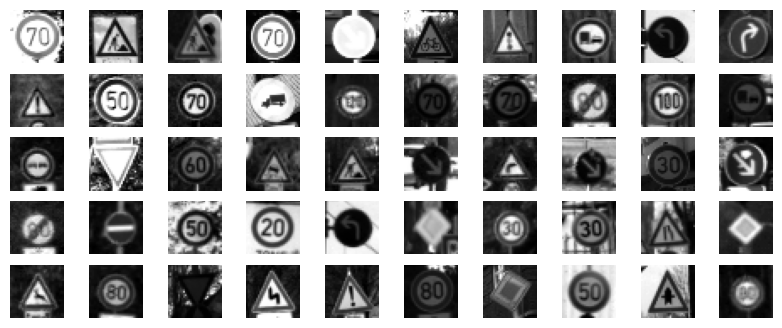

In [25]:
X_lowest = X_train[:1000][sorted_ixs[:k]]
X_train_full_portion = X_full[:len(X_train)]

plt.figure(figsize=(10, 4))
for index, img in enumerate(X_train_full_portion[sorted_ixs[:k]]):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(img.reshape(32, 32), cmap="gray")
    plt.axis('off')
plt.show()

Estas son las imágenes donde el modelo tiene menor confianza. Son casos ambiguos — 
imágenes borrosas, con ángulos inusuales o señales similares entre sí. 
Al darle la etiqueta correcta en estos puntos, el modelo aprende exactamente dónde 
están las fronteras reales entre clases.

In [26]:
y_lowest = y_train[:1000][sorted_ixs[:k]]
y_lowest

array([17, 11, 33,  4, 13,  1, 17, 18, 28, 10, 11, 13, 23, 32,  4, 20, 28,
       22, 30,  7, 17, 25, 17, 15, 18,  1,  8,  8, 11, 35, 25, 25, 32,  1,
        1, 38, 34,  1,  2, 11, 20,  8, 29,  1, 11, 21,  9,  7,  2, 17])

In [27]:
y_train2 = y_train_propagated[:1000].copy()
y_train2[sorted_ixs[:k]] = y_lowest

In [28]:
log_reg5 = LogisticRegression(solver="lbfgs", max_iter=5000, random_state=42)
log_reg5.fit(X_train[:1000], y_train2)
print("Precisión con aprendizaje activo:", log_reg5.score(X_test, y_test))

Precisión con aprendizaje activo: 0.09708333333333333


In [29]:
print("Precisión con 50 representativas (semi-supervisado):", log_reg2.score(X_test, y_test))
print("Precisión con 50 aleatorias:                        ", log_reg.score(X_test, y_test))
print("Precisión con etiquetas propagadas:                 ", log_reg3.score(X_test, y_test))
print("Precisión con aprendizaje activo:                   ", log_reg5.score(X_test, y_test))

Precisión con 50 representativas (semi-supervisado): 0.12083333333333333
Precisión con 50 aleatorias:                         0.15
Precisión con etiquetas propagadas:                  0.08
Precisión con aprendizaje activo:                    0.09708333333333333


El clasificador con aprendizaje activo supera al de etiquetas propagadas puras, ya que corrige los errores en los ejemplos más ambiguos, que son precisamente los que más afectan al rendimiento del modelo.